# Exercice 2.17 #

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Paramètres du model ###

In [2]:
T = 10.0  # Temps final
h = 0.001 # Pas de temps
N = int(T / h)  # Nombre de pas
lambda_val = 0.  # Valeur de lambda
x_0 = 0.  # Condition initiale

### Schéma Euler explicite ###

In [3]:
def f(t,x):
    return 2 * np.sqrt(np.abs(x))


# Fonction pour le schéma d'Euler explicit
def euler_explicit(T, N, lambda_val, x_0):
    h = T / N
    t = np.linspace(0, T, N+1)
    x = np.zeros(N+1)
    x[0] = x_0  # Condition initiale

    for i in range(1, N+1):
        x[i] = x[i-1] + h * f(t[i-1], x[i-1])
 
    return t, x

### Schéma Euler implicite ###

In [4]:
# Fonction pour résoudre équation du second degré
def solve_quadratic(a,b,c):

    coefficients = [a, b, c]
    solutions = np.roots(coefficients)

    return solutions

# Fonction pour le schéma d'Euler implicit
def euler_implicit(T, N, lambda_val, x_0):
    h = T / N
    t = np.linspace(0, T, N+1)
    x = np.zeros(N+1)
    x[0] = x_0  # Condition initiale

    for i in range(1, N+1):
        # x[i] = np.sqrt(solve_quadratic(1, -4*h, -x[i-1])[0])
        x[i] = (h + np.sqrt(h**2 + x[i-1]))**2

    return t, x

### Calcul des solutions ###

In [5]:
t_explicit, x_explicit = euler_explicit(T, N, lambda_val, x_0)
t_implicit, x_implicit = euler_implicit(T, N, lambda_val, x_0)

# Solution exacte
# def x_exact(t, lambda_val):
#     if t >= lambda_val:
#         return (t-lambda_val)**2
#     else:
#         return 0

x_exact = np.where(t_explicit >= lambda_val, (t_explicit - lambda_val)**2, 0)

### Tracé des résultats ###

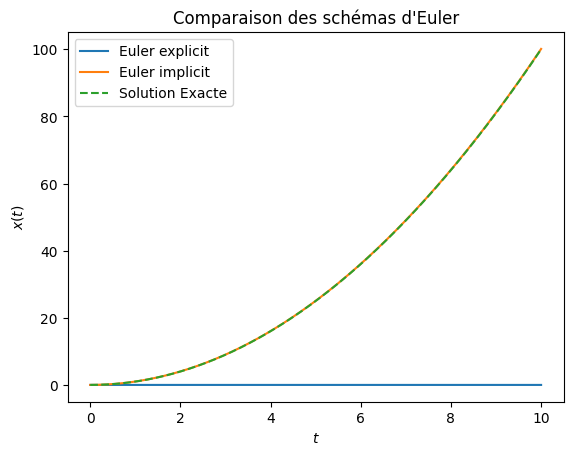

In [ ]:
plt.figure()
plt.plot(t_explicit, x_explicit, label='Euler explicit')
plt.plot(t_implicit, x_implicit, label='Euler implicit')
plt.plot(t_explicit, x_exact, label='Solution Exacte', linestyle='--')
plt.xlabel(r'$t$')
plt.ylabel(r'$x(t)$')
plt.legend()
plt.title('Comparaison des schémas d\'Euler')
plt.show()

### Erreur d'approximation $L^2$ ###

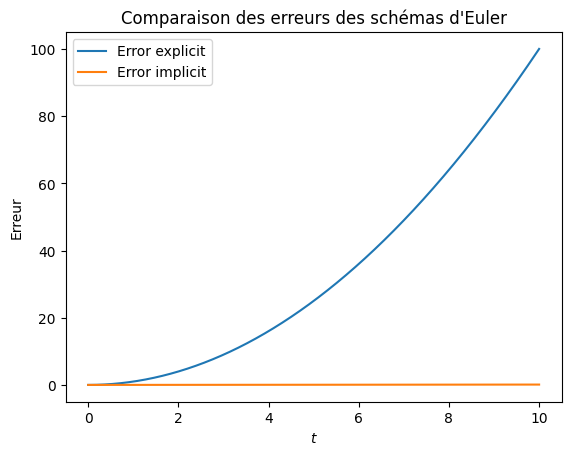

Erreur du schéma explicite : 100.0
Erreur du schéma implicite: 0.10506565476141816


In [9]:
error_explicit = np.sqrt((x_explicit - x_exact)**2)
error_implicit = np.sqrt((x_implicit - x_exact)**2)
plt.figure()
plt.plot(t_explicit, error_explicit, label = 'Error explicit')
plt.plot(t_explicit, error_implicit, label = 'Error implicit')
plt.xlabel(r'$t$')
plt.ylabel('Erreur')
plt.legend()
plt.title('Comparaison des erreurs des schémas d\'Euler')
plt.show()

print("Erreur du schéma explicite :", np.max(error_explicit))
print("Erreur du schéma implicite:", np.max(error_implicit))